In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh
from scipy.optimize import minimize_scalar, root


#параметр распределения
sgm = 4.0

#выборка
np.random.seed(42)
main = rayleigh.rvs(scale=sgm, size=10000)

In [4]:
def generate(sigma, N, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
    return rayleigh.rvs(scale=sigma, size=N)

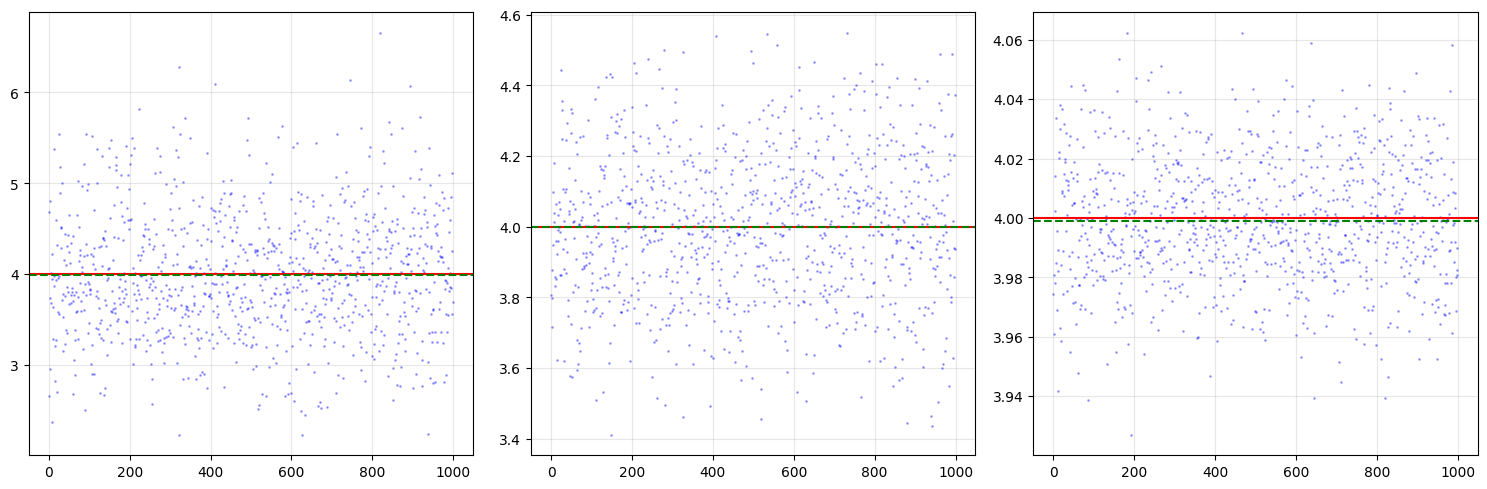

In [5]:
#2.1
# оценка параметра методом моментов
def sgmMoments(sample):
    return np.mean(sample) / np.sqrt(np.pi / 2)

# поведение оценки
def analyzeMoments(values, n):
    fig, axes = plt.subplots(1, len(values), figsize=(15, 5))
    
    results = {}
    for idx, N in enumerate(values):
        estimates = np.zeros(n)
        for i in range(n):
            sample = generate(sgm, N, random_seed=i)
            estimates[i] = sgmMoments(sample)
        
        results[N] = estimates
        
        axes[idx].plot(range(n), estimates, 'b.', alpha=0.3, markersize=2)
        axes[idx].axhline(y=sgm, color='r', linestyle='-')
        axes[idx].axhline(y=np.mean(estimates), color='g', linestyle='--')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    return results

result = analyzeMoments([10, 100, 10000], 1000)

Оценка ММП: σ̂ = 3.954742


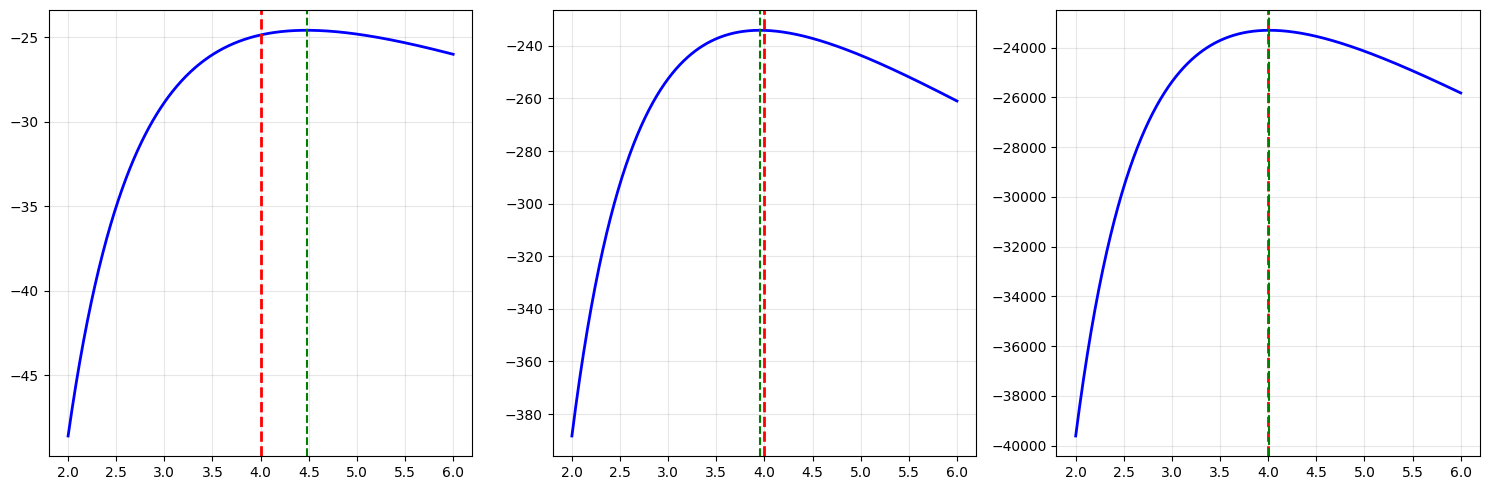

In [ ]:
#2.2
# Определяем функцию правдоподобия и её производную
def likelihood(sample, sigma = sgm):
    n = len(sample)
    return np.prod(sample) / (sigma**(2*n)) * np.exp(-np.sum(sample**2) / (2*sigma**2))

def logLH(sample, sigma = sgm):
    n = len(sample)
    return np.sum(np.log(sample)) - 2*n*np.log(sigma) - np.sum(sample**2) / (2*sigma**2)

def derivativeLH(sample, sigma = sgm): 
    n = len(sample)
    return -2 * n / sigma + np.sum(sample**2) / (sigma**3)

def solve(sample, sigma_initial=None):
    if sigma_initial is None:
        sigma_initial = np.mean(sample) * np.sqrt(2 / np.pi)
    
    def equation(sgm):
        return derivativeLH(sample, sgm)
    
    result = root(equation, sigma_initial, method='hybr')
    return result.x[0]

# Находим оценку ММП через решение уравнения
sigma_mle = solve(main)

print(f"Оценка ММП: σ̂ = {sigma_mle:.6f}")

def likelihoodFunc(values):
    fig, axes = plt.subplots(1, len(values), figsize=(15, 5))
    sgmRange = np.linspace(2, 6, 500)
    
    for idx, N in enumerate(values):
        sample = generate(sgm, N)
        
        lh = np.array([logLH(sample, s) for s in sgmRange])
        ml = solve(sample)
        
        axes[idx].plot(sgmRange, lh, 'b-', linewidth=2)
        axes[idx].axvline(sgm, color='r', linestyle='--', linewidth=2)
        axes[idx].axvline(x=ml, color='g', linestyle='--')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

likelihoodFunc([10, 100, 10000])

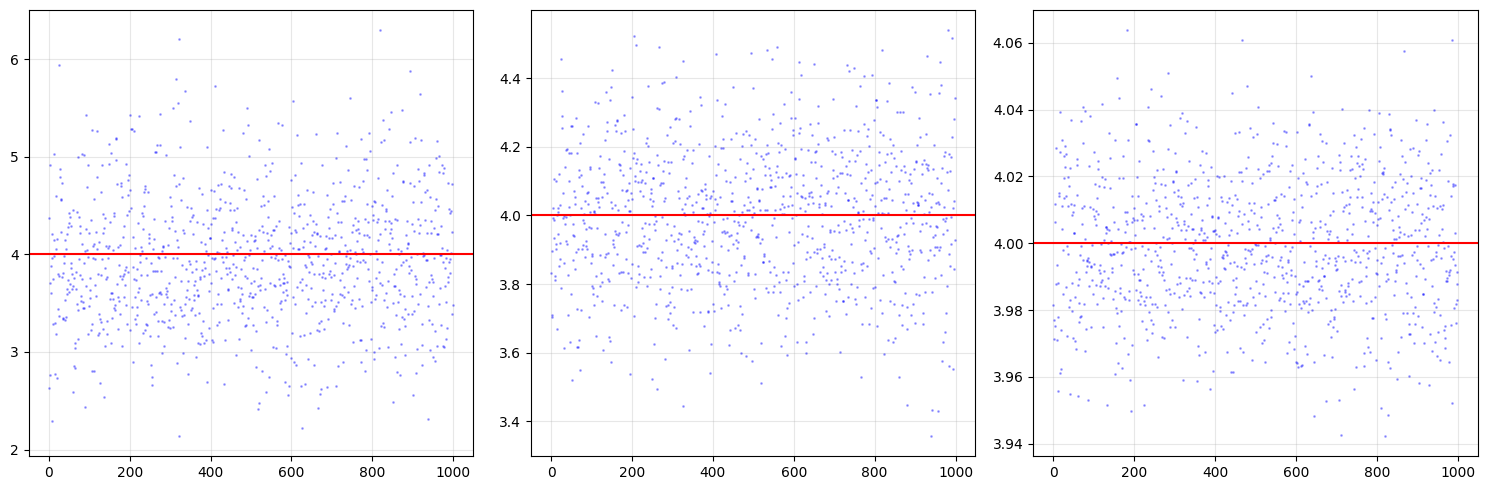

In [26]:
# Анализ поведения ММП оценки при разных объемах выборки
def analyzeEstimator(values, n):
    fig, axes = plt.subplots(1, len(values), figsize=(15, 5))
    
    results = {}
    for idx, N in enumerate(values):
        estimates = np.zeros(n)
        for i in range(n):
            sample = generate(sgm, N, random_seed=i)
            estimates[i] = solve(sample)
        
        results[N] = estimates
        
        axes[idx].plot(range(n), estimates, 'b.', alpha=0.3, markersize=2)
        axes[idx].axhline(y=sgm, color='r', linestyle='-')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    return results

results_ml = analyzeEstimator([10, 100, 10000], 1000)

In [29]:
#2.3
def computeStats(nReal, N):
    moments_estimates = np.zeros(nReal)
    ml_estimates = np.zeros(nReal)
    
    for i in range(nReal):
        sample = generate(sgm, N, random_seed=i)
        moments_estimates[i] = sgmMoments(sample)
        ml_estimates[i] = solve(sample)
    
    # Статистики для метода моментов
    bias_moments = np.mean(moments_estimates) - sgm
    var_moments = np.var(moments_estimates)
    mse_moments = np.mean((moments_estimates - sgm)**2)
    
    # Статистики для ММП
    bias_ml = np.mean(ml_estimates) - sgm
    var_ml = np.var(ml_estimates)
    mse_ml = np.mean((ml_estimates - sgm)**2)
    
    print(f"{'Метод':<20} {'Смещение':<15} {'Дисперсия':<15} {'MSE':<15}")
    print(f"{'Метод моментов':<20} {bias_moments:+.6f}       {var_moments:.6f}       {mse_moments:.6f}")
    print(f"{'ММП':<20} {bias_ml:+.6f}       {var_ml:.6f}       {mse_ml:.6f}")
    
    return moments_estimates, ml_estimates

moments_est, ml_est = computeStats(100, 100)

Метод                Смещение        Дисперсия       MSE            
Метод моментов       -0.030409       0.036395       0.037320
ММП                  -0.029104       0.033757       0.034604


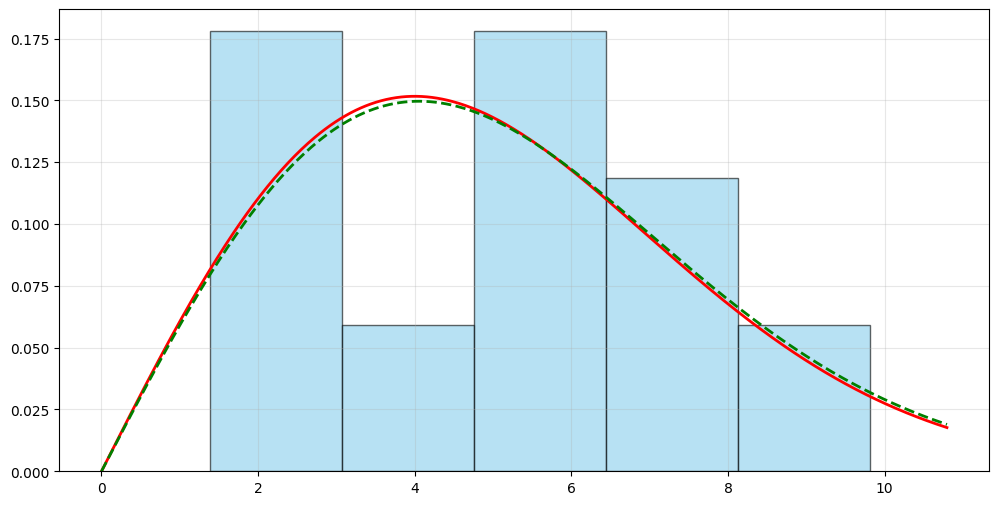

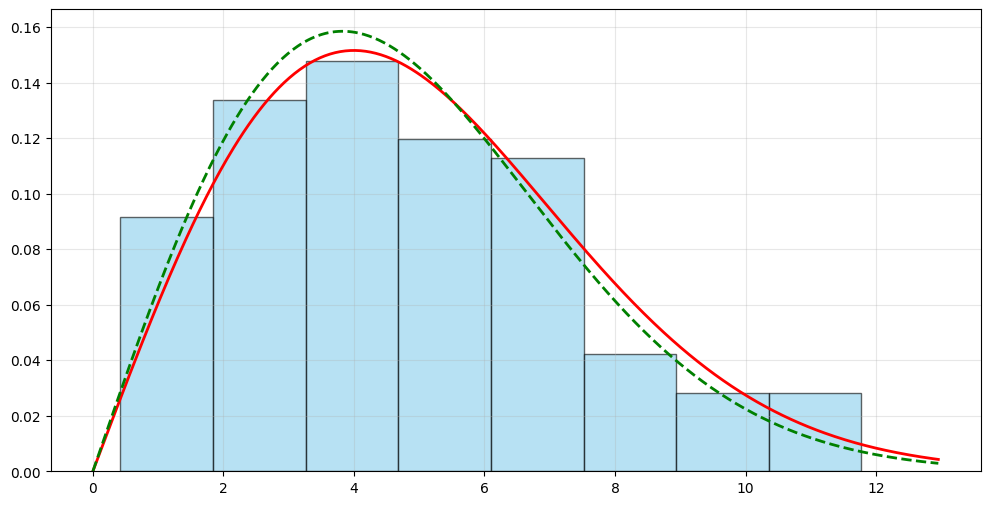

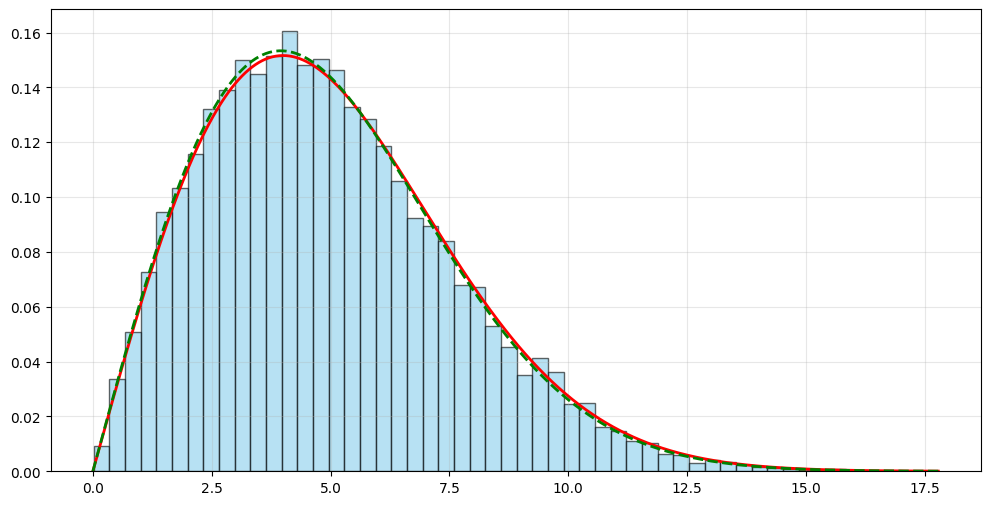

In [30]:
#3
def histogram(N, random_seed=42):
    sample = generate(sgm, N, random_seed=random_seed)
    
    # Оценка параметра методом ММП
    sigma_est = solve(sample)
    
    # Построение гистограммы
    plt.figure(figsize=(12, 6))
    
    # Гистограмма относительных частот
    counts, bins, patches = plt.hist(sample, bins='auto', density=True, alpha=0.6, color='skyblue', edgecolor='black')
    
    # Теоретическая плотность с истинным параметром
    x_range = np.linspace(0, max(sample) * 1.1, 500)
    true_pdf = rayleigh.pdf(x_range, scale=sgm)
    plt.plot(x_range, true_pdf, 'r-', linewidth=2)
    
    # Теоретическая плотность с оценкой параметра
    est_pdf = rayleigh.pdf(x_range, scale=sigma_est)
    plt.plot(x_range, est_pdf, 'g--', linewidth=2)
    
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return sample, sigma_est

# Построение для разных N
for N in [10, 100, 10000]:
    sample, sigma_est = histogram(N, random_seed=42)

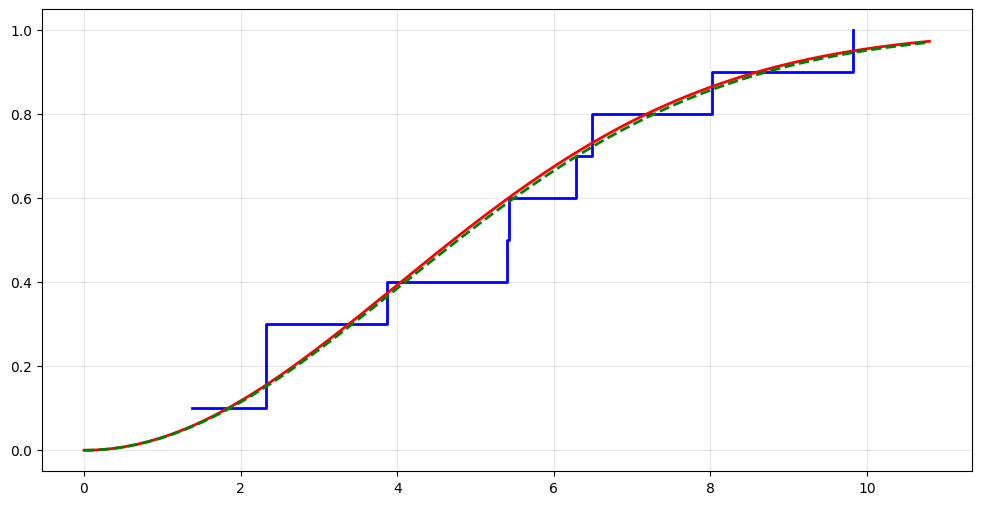

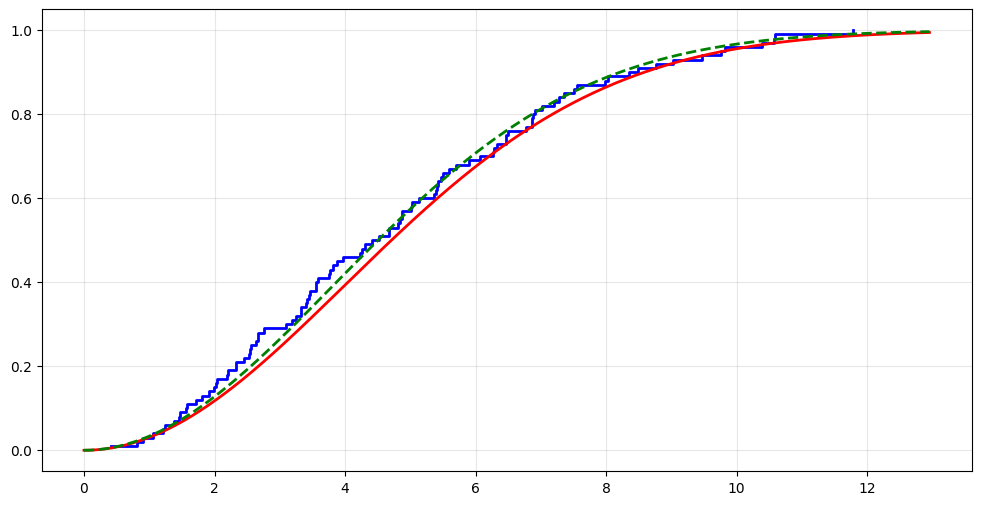

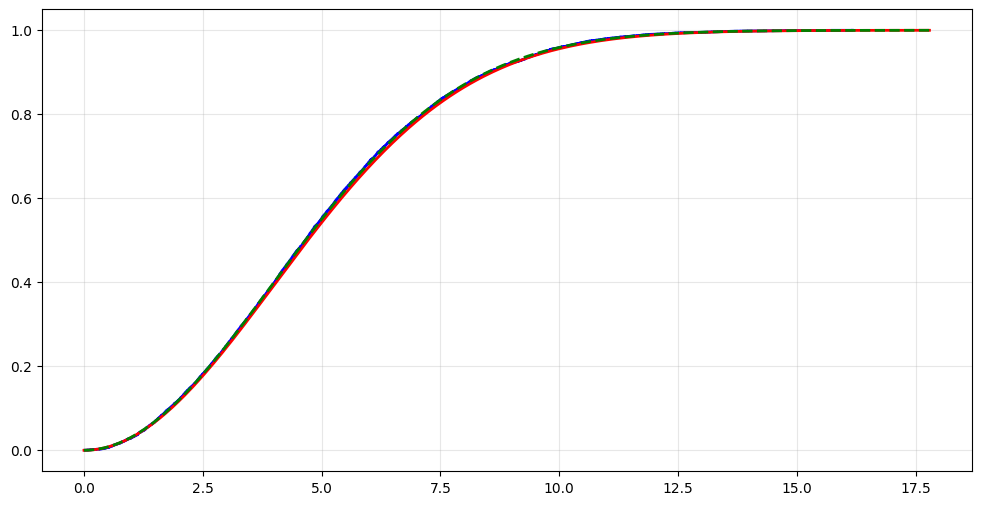

In [31]:
def plotECDF(N, random_seed=42):
    sample = generate(sgm, N, random_seed=random_seed)
    sigma_est = solve(sample)
    
    plt.figure(figsize=(12, 6))
    
    # Эмпирическая функция распределения
    x_sorted = np.sort(sample)
    ecdf = np.arange(1, len(sample) + 1) / len(sample)
    plt.step(x_sorted, ecdf, 'b-', linewidth=2, where='post')
    
    # Теоретическая ФР с истинным параметром
    x_range = np.linspace(0, max(sample) * 1.1, 500)
    true_cdf = rayleigh.cdf(x_range, scale=sgm)
    plt.plot(x_range, true_cdf, 'r-', linewidth=2)
    
    # Теоретическая ФР с оценкой параметра
    est_cdf = rayleigh.cdf(x_range, scale=sigma_est)
    plt.plot(x_range, est_cdf, 'g--', linewidth=2)
    
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.show()
    
    return sample, sigma_est

# Построение для разных N
for N in [10, 100, 10000]:
    sample, sigma_est = plotECDF(N, random_seed=42)